# Monte Carlo Revenue-at-Risk and Pricing Scenario Simulator

This project looks at how subscription prices affect revenue, customer retention and contribution over 12 months.
All business data and assumptions are synthetic. Plan prices and revenue exclude tax. Local costs are in TRY; some service costs are in USD.

Run the modules in order. The forecast uses customer equivalents, so decimal customer counts are expected.

## Module 1 - Import libraries

In [1]:
# Module 1: Import libraries

%matplotlib inline

import warnings
import numpy as np
with warnings.catch_warnings():
    # Ignore optional pandas accelerator warnings in older environments.
    warnings.filterwarnings("ignore", message="Pandas requires version.*", category=UserWarning)
    import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit, logit
from IPython.display import display

# Use the same plot style throughout the notebook.
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.spines.top": False,
                     "axes.spines.right": False, "grid.alpha": 0.25})
pd.options.display.float_format = "{:,.2f}".format

## Module 2 - Set up subscription plans

In [2]:
# Module 2: Set up subscription plans

# Set the starting exchange rate in one place.
# Example: usdtry = 50 means 1 USD costs 50 TRY.
usdtry = 51.0

# Plan prices exclude tax. Customers pay the price plus 25% tax.
tax_rate = 0.25
payment_commission_rate = 0.015

# Prices, local costs and acquisition costs are in TRY.
# USD service costs stay in USD because the exchange rate will change during the simulation.
plans = pd.DataFrame({
    "plan": ["Basic", "Standard", "Premium"],
    "price_excl_tax": [199.0, 279.0, 399.0],
    "usd_cost_usd": [1.0, 1.8, 3.2],
    "acquisition_cost": [350.0, 600.0, 900.0],
    "target_gross_margin": [0.20, 0.225, 0.25],
}).set_index("plan")

# Set local costs so starting gross margins are 20%, 22.5% and 25%.
# Payment commission is charged on the tax-inclusive customer payment.
plans["starting_usd_cost_try"] = plans["usd_cost_usd"] * usdtry
plans["customer_price_incl_tax"] = plans["price_excl_tax"] * (1 + tax_rate)
plans["starting_payment_commission"] = plans["customer_price_incl_tax"] * payment_commission_rate
plans["local_cost"] = (plans["price_excl_tax"] * (1 - plans["target_gross_margin"])
                       - plans["starting_usd_cost_try"]
                       - plans["starting_payment_commission"])
plans["starting_gross_margin"] = (
    plans["price_excl_tax"] - plans["local_cost"] - plans["starting_usd_cost_try"]
    - plans["starting_payment_commission"]
) / plans["price_excl_tax"]

plans[["price_excl_tax", "customer_price_incl_tax", "local_cost", "usd_cost_usd",
       "starting_payment_commission", "starting_gross_margin", "acquisition_cost"]]

,price_excl_tax,customer_price_incl_tax,local_cost,usd_cost_usd,starting_payment_commission,starting_gross_margin,acquisition_cost
plan,,,,,,,
Basic,199.00,248.75,104.47,1.00,3.73,0.20,350.00
Standard,279.00,348.75,119.19,1.80,5.23,0.23,600.00
Premium,399.00,498.75,128.57,3.20,7.48,0.25,900.00


## Module 3 - Set up customer segments

In [3]:
# Module 3: Set up customer segments

# A larger elasticity means that new customers react more strongly to price.
# Price response controls the temporary increase in churn after a price change.
segments = pd.DataFrame({
    "segment": ["Value seekers", "Mainstream", "Power users"],
    "base_churn": [0.022, 0.016, 0.011],
    "elasticity": [2.0, 1.35, 0.90],
    "price_response": [8.0, 6.0, 4.0],
    "price_burden": [1.5, 1.0, 0.6],
}).set_index("segment")

segments

,base_churn,elasticity,price_response,price_burden
segment,,,,
Value seekers,0.02,2.00,8.00,1.50
Mainstream,0.02,1.35,6.00,1.00
Power users,0.01,0.90,4.00,0.60


## Module 4 - Build the starting customer table

In [4]:
# Module 4: Build the starting customer table

# Each row represents one segment and one plan.
# Keeping nine groups is enough for this analysis; individual customer IDs add no value here.
target_starting_customers = 100_000
base_opening_counts = np.array([4200, 1400, 400, 2300, 2600, 1100, 400, 900, 1700])
base_monthly_signups = np.array([145, 70, 20, 80, 140, 75, 15, 45, 90])

# Scale the original customer mix from 15,000 to the chosen company size.
company_scale = target_starting_customers / base_opening_counts.sum()
opening_counts = np.rint(base_opening_counts * company_scale).astype(int)
opening_counts[-1] += target_starting_customers - opening_counts.sum()

# Use a slower acquisition plan instead of scaling signups directly with company size.
# At the starting point, gross signups equal 2% of the customer base per month.
target_monthly_signups = int(target_starting_customers * 0.02)
monthly_signups = np.rint(base_monthly_signups / base_monthly_signups.sum()
                          * target_monthly_signups).astype(int)
monthly_signups[-1] += target_monthly_signups - monthly_signups.sum()

groups = pd.MultiIndex.from_product(
    [segments.index, plans.index], names=["segment", "plan"]
).to_frame(index=False)
groups["customers"] = opening_counts
groups["new_customers"] = monthly_signups
groups = groups.join(plans, on="plan").join(segments, on="segment")
groups["starting_revenue"] = groups["customers"] * groups["price_excl_tax"]

groups[["segment", "plan", "customers", "new_customers", "starting_revenue"]]

,segment,plan,customers,new_customers,starting_revenue
0,Value seekers,Basic,28000,426,"5,572,000.00"
1,Value seekers,Standard,9333,206,"2,603,907.00"
2,Value seekers,Premium,2667,59,"1,064,133.00"
3,Mainstream,Basic,15333,235,"3,051,267.00"
4,Mainstream,Standard,17333,412,"4,835,907.00"
5,Mainstream,Premium,7333,221,"2,925,867.00"
6,Power users,Basic,2667,44,"530,733.00"
7,Power users,Standard,6000,132,"1,674,000.00"
8,Power users,Premium,11334,265,"4,522,266.00"


## Module 5 - Look at the starting business

Starting customers: 100,000
Monthly net revenue: TRY 26.78 million
Monthly customer bill including tax: TRY 33.48 million
Annualized net revenue: TRY 321.36 million
Planned monthly gross signups: 2,000


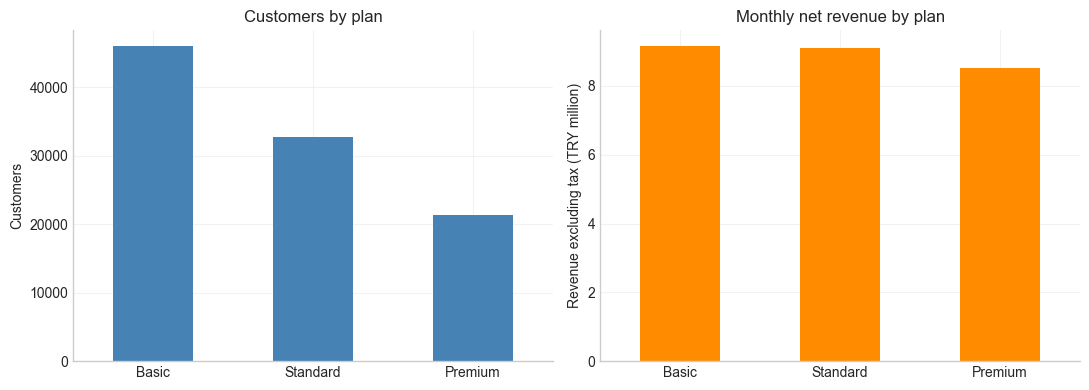

In [5]:
# Module 5: Look at the starting business

# The annualized starting revenue is a snapshot, not a forecast.
starting_revenue = groups["starting_revenue"].sum()
starting_customer_bill = starting_revenue * (1 + tax_rate)
print(f"Starting customers: {groups['customers'].sum():,}")
print(f"Monthly net revenue: TRY {starting_revenue / 1e6:.2f} million")
print(f"Monthly customer bill including tax: TRY {starting_customer_bill / 1e6:.2f} million")
print(f"Annualized net revenue: TRY {starting_revenue * 12 / 1e6:.2f} million")
print(f"Planned monthly gross signups: {groups['new_customers'].sum():,.0f}")

by_plan = groups.groupby("plan")[["customers", "starting_revenue"]].sum().reindex(plans.index)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
by_plan["customers"].plot.bar(ax=axes[0], color="steelblue", rot=0)
(by_plan["starting_revenue"] / 1e6).plot.bar(ax=axes[1], color="darkorange", rot=0)
axes[0].set(title="Customers by plan", xlabel="", ylabel="Customers")
axes[1].set(title="Monthly net revenue by plan", xlabel="", ylabel="Revenue excluding tax (TRY million)")
plt.tight_layout()
plt.show()

## Module 6 - Choose the main assumptions

In [6]:
# Module 6: Choose the main assumptions

# Change these settings to try a different business case.
n_months = 12
n_simulations = 5000
seed = 42

assumptions = {
    # Use the exchange-rate parameter defined in Module 2.
    "starting_fx": usdtry,
    "year_end_fx": 60.0,
    "annual_inflation": 0.30,
    "annual_demand_trend": -0.06,
    # Fixed costs are entered directly instead of scaling linearly with customers.
    "monthly_fixed_cost": 3_000_000.0,
    "income_pass_through": 0.65,
    "price_memory": 0.55,
}

# The target is set from the no-price-change benchmark later in the notebook.
target_growth = 0.05
risk_limit = 0.35
# Allow a maximum 5% decline while preventing aggressive pricing from shrinking the base too far.
customer_floor = target_starting_customers * 0.95

# Positive inflation and FX shocks tend to occur alongside weaker demand.
correlation = np.array([[1.00, 0.60, -0.45],
                        [0.60, 1.00, -0.35],
                        [-0.45, -0.35, 1.00]])

## Module 7 - Generate possible economic conditions

Inflation, exchange rates and demand share correlated shocks. Customer behavior also varies between simulations.

In [7]:
# Module 7: Generate possible economic conditions

def create_conditions(n_paths, random_seed, uncertain=True):
    # Rows are simulation paths; columns are months.
    rng = np.random.default_rng(random_seed)
    noise = rng.normal(size=(n_paths, n_months, 3))
    noise = noise @ np.linalg.cholesky(correlation).T
    inflation_total_growth = np.full(n_paths, np.log1p(assumptions["annual_inflation"]))
    fx_total_growth = np.full(n_paths, np.log(assumptions["year_end_fx"] / assumptions["starting_fx"]))
    demand_trend = np.full(n_paths, assumptions["annual_demand_trend"])

    # Draw behavior assumptions once per path; monthly shocks are separate.
    elasticity = np.tile(segments["elasticity"].to_numpy(), (n_paths, 1))
    churn = np.tile(segments["base_churn"].to_numpy(), (n_paths, 1))
    response = np.tile(segments["price_response"].to_numpy(), (n_paths, 1))
    if uncertain:
        inflation_total_growth += rng.normal(0, 0.07, n_paths)
        fx_total_growth += rng.normal(0, 0.12, n_paths)
        demand_trend += rng.normal(0, 0.08, n_paths)
        elasticity = np.clip(rng.normal(elasticity, elasticity * 0.20), 0.1, 6.0)
        churn = expit(logit(churn) + rng.normal(0, 0.18, churn.shape))
        response *= rng.uniform(0.8, 1.2, response.shape)
    else:
        noise[:] = 0

    # Month 1 starts at CPI = 1 and the starting FX rate.
    # Without random shocks, month 12 reaches CPI = 1.30 and FX = 60 TRY/USD.
    cpi = np.ones((n_paths, n_months))
    fx = np.full((n_paths, n_months), assumptions["starting_fx"])
    demand = np.zeros((n_paths, n_months))
    demand_state = np.zeros(n_paths)
    yearly_steps = max(n_months - 1, 1)
    for month in range(n_months):
        demand_state = 0.6 * demand_state + 0.8 * noise[:, month, 2]
        demand[:, month] = demand_trend * month / yearly_steps + 0.10 * demand_state
        if month > 0:
            cpi[:, month] = cpi[:, month - 1] * np.exp(inflation_total_growth / yearly_steps + 0.006 * noise[:, month, 0])
            fx[:, month] = fx[:, month - 1] * np.exp(fx_total_growth / yearly_steps + 0.035 * noise[:, month, 1])

    # Every segment has three plans, so repeat its behavior across three group columns.
    return {"cpi": cpi, "fx": fx, "demand": demand,
            "elasticity": np.repeat(elasticity, 3, axis=1),
            "churn": np.repeat(churn, 3, axis=1),
            "response": np.repeat(response, 3, axis=1),
            "extra_churn": np.zeros((n_paths, n_months))}

conditions = create_conditions(n_simulations, seed)

## Module 8 - Plot the economic scenarios

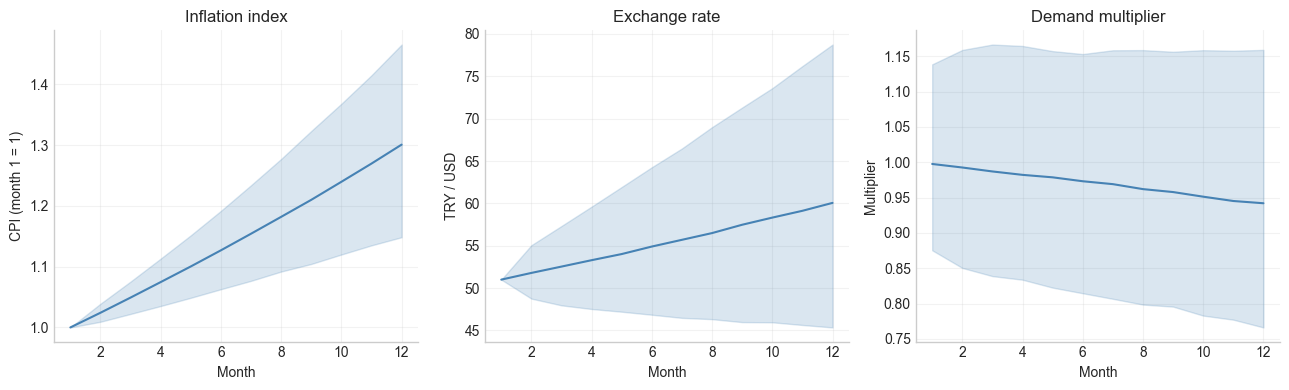

In [8]:
# Module 8: Plot the economic scenarios

# Show the median and the middle 90% of simulated outcomes.
months = np.arange(1, n_months + 1)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
series = [conditions["cpi"], conditions["fx"], np.exp(conditions["demand"])]
titles = ["Inflation index", "Exchange rate", "Demand multiplier"]
labels = ["CPI (month 1 = 1)", "TRY / USD", "Multiplier"]
for ax, values, title, label in zip(axes, series, titles, labels):
    low, median, high = np.percentile(values, [5, 50, 95], axis=0)
    ax.plot(months, median, color="steelblue")
    ax.fill_between(months, low, high, color="steelblue", alpha=0.2)
    ax.set(title=title, xlabel="Month", ylabel=label)
plt.tight_layout()
plt.show()

## Module 9 - Define the pricing scenarios

The protected scenario delays the increase for the starting customers until month 7. New signups pay the higher price immediately.

In [9]:
# Module 9: Define the pricing scenarios

scenarios = {
    "No increase": {"type": "fixed", "increase": 0.0},
    "Upfront 25%": {"type": "fixed", "increase": 0.25},
    "Staged 25%": {"type": "staged", "increase": 0.25},
    "Inflation linked": {"type": "inflation"},
    "Plan-based increase": {"type": "tiered", "increases": [0.12, 0.25, 0.35]},
    "Protect existing customers": {"type": "protected", "increase": 0.25},
}

def get_prices(scenario, economy):
    # Array order: simulation, month, customer group, billing cohort.
    # Cohort 0 is the starting book; cohort 1 contains later signups.
    n_paths = economy["cpi"].shape[0]
    prices = np.broadcast_to(groups["price_excl_tax"].to_numpy()[None, None, :, None],
                             (n_paths, n_months, len(groups), 2)).copy()
    kind = scenario["type"]
    if kind in ["fixed", "protected"]:
        prices *= 1 + scenario["increase"]
        if kind == "protected":
            prices[:, :6, :, 0] = groups["price_excl_tax"].to_numpy()
    elif kind == "staged":
        # Two equal percentage steps reach the stated total increase.
        prices[:, :6] *= np.sqrt(1 + scenario["increase"])
        prices[:, 6:] *= 1 + scenario["increase"]
    elif kind == "tiered":
        prices *= np.tile(1 + np.array(scenario["increases"]), 3)[None, None, :, None]
    elif kind == "inflation":
        factor = np.ones(n_paths)
        for month in range(n_months):
            if month > 0 and month % 3 == 0:
                # Review quarterly using only last month's known CPI.
                # Limit each increase to 12%; do not reduce prices.
                factor *= np.clip(economy["cpi"][:, month - 1] / factor, 1, 1.12)
            prices[:, month] *= factor[:, None, None]
    else:
        raise ValueError("Unknown pricing scenario")
    return prices

## Module 10 - Check the monthly prices

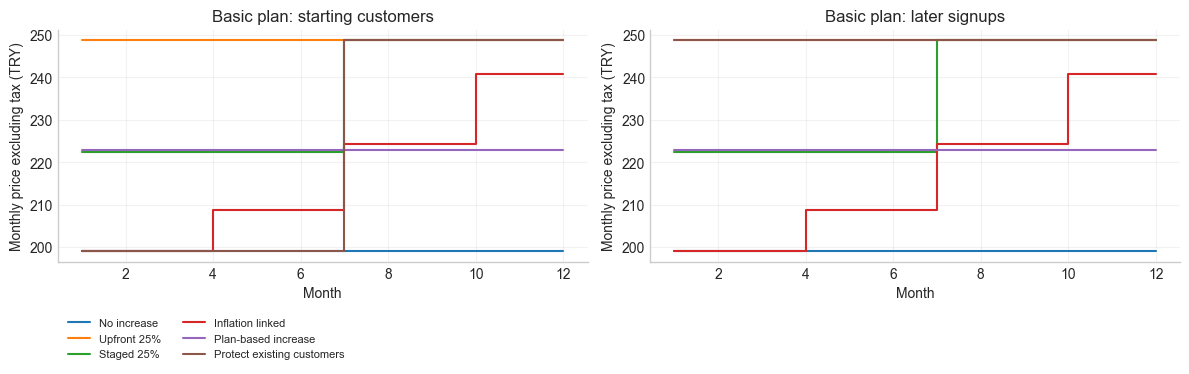

In [10]:
# Module 10: Check the monthly prices

# Use one steady economic path to make the pricing rules easy to see.
steady_conditions = create_conditions(1, seed, uncertain=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, scenario in scenarios.items():
    prices = get_prices(scenario, steady_conditions)
    for cohort, ax in enumerate(axes):
        ax.step(months, prices[0, :, 0, cohort], where="post", label=name)
axes[0].set(title="Basic plan: starting customers", xlabel="Month", ylabel="Monthly price excluding tax (TRY)")
axes[1].set(title="Basic plan: later signups", xlabel="Month", ylabel="Monthly price excluding tax (TRY)")
axes[0].legend(fontsize=8, loc="upper left", bbox_to_anchor=(0, -0.2), ncol=2)
plt.tight_layout()
plt.show()

## Module 11 - Calculate new customer demand

In [11]:
# Module 11: Calculate new customer demand

def calculate_signups(current_prices, economy, month):
    # Let the reference purchasing budget follow part of inflation.
    budget = economy["cpi"][:, month] ** assumptions["income_pass_through"]
    price_ratio = current_prices[:, :, 1] / (groups["price_excl_tax"].to_numpy() * budget[:, None])

    # A higher real price reduces signups according to price elasticity.
    # Seasonality is shared across all pricing scenarios.
    seasonal_factor = 1 + 0.10 * np.sin(2 * np.pi * month / 12)
    signups = (groups["new_customers"].to_numpy()[None, :]
               * seasonal_factor
               * np.exp(economy["demand"][:, month, None])
               * price_ratio ** (-economy["elasticity"]))
    return signups

## Module 12 - Calculate customer churn

Acquisition elasticity applies to new customers. Churn applies to customers who were already subscribed at the start of the month.

In [12]:
# Module 12: Calculate customer churn

def calculate_churn(opening, current_prices, previous_prices, memory, economy, month):
    # Existing customers remember recent price increases; the effect fades each month.
    price_step = np.maximum(np.log(current_prices / previous_prices), 0)
    memory = np.where(opening > 0, assumptions["price_memory"] * memory + price_step, 0)

    budget = economy["cpi"][:, month] ** assumptions["income_pass_through"]
    real_ratio = current_prices / (groups["price_excl_tax"].to_numpy()[None, :, None] * budget[:, None, None])
    price_burden = np.maximum(np.log(real_ratio), 0)

    # Logistic probabilities stay between zero and one.
    churn_score = (logit(economy["churn"])[:, :, None]
                   + economy["response"][:, :, None] * memory
                   + groups["price_burden"].to_numpy()[None, :, None] * price_burden
                   - 1.2 * economy["demand"][:, month, None, None]
                   + economy["extra_churn"][:, month, None, None])
    return expit(churn_score), memory

## Module 13 - Calculate revenue and costs

**Contribution = net revenue − service costs − payment commission.** Tax is added to the customer bill but is not recorded as revenue. The operating result also deducts acquisition spending and fixed costs.

In [13]:
# Module 13: Calculate revenue and costs

def calculate_financials(opening, lost, acquired, current_prices, economy, month):
    # Customers who join or leave are billed for half a month on average.
    exposure = opening - 0.5 * lost + 0.5 * acquired
    net_revenue_by_group = (exposure * current_prices).sum(axis=2)
    net_revenue = net_revenue_by_group.sum(axis=1)

    # Tax is collected from customers but is not company revenue.
    tax_collected = net_revenue * tax_rate
    customer_payment = net_revenue + tax_collected
    payment_commission = customer_payment * payment_commission_rate

    # Local costs follow inflation; USD service costs follow the exchange rate.
    service_per_customer = (groups["local_cost"].to_numpy() * economy["cpi"][:, month, None]
                            + groups["usd_cost_usd"].to_numpy() * economy["fx"][:, month, None])
    service_cost = (exposure * service_per_customer[:, :, None]).sum(axis=(1, 2))
    acquisition_cost = (acquired[:, :, 1] * groups["acquisition_cost"].to_numpy()
                        * economy["cpi"][:, month, None]).sum(axis=1)
    fixed_cost = assumptions["monthly_fixed_cost"] * economy["cpi"][:, month]

    contribution = net_revenue - service_cost - payment_commission
    operating_result = contribution - acquisition_cost - fixed_cost
    return (net_revenue, contribution, operating_result, net_revenue_by_group,
            tax_collected, payment_commission)

## Module 14 - Run the monthly business model

Each month: calculate departures, add signups, update customers, then calculate revenue and costs. New signups can leave from the following month.

In [14]:
# Module 14: Run the monthly business model

def simulate(scenario, economy):
    n_paths = economy["cpi"].shape[0]
    prices = get_prices(scenario, economy)

    # Track starting customers and later signups separately.
    customers = np.zeros((n_paths, len(groups), 2))
    customers[:, :, 0] = groups["customers"].to_numpy()
    previous_prices = np.broadcast_to(groups["price_excl_tax"].to_numpy()[None, :, None], customers.shape).copy()
    memory = np.zeros_like(customers)

    result = {name: np.zeros((n_paths, n_months)) for name in
              ["revenue", "contribution", "operating_result", "tax_collected",
               "payment_commission", "customers", "signups", "lost"]}
    result["group_revenue"] = np.zeros((n_paths, len(groups)))

    for month in range(n_months):
        opening = customers.copy()
        current_prices = prices[:, month]
        churn, memory = calculate_churn(opening, current_prices, previous_prices,
                                        memory, economy, month)
        lost = opening * churn
        acquired = np.zeros_like(customers)
        acquired[:, :, 1] = calculate_signups(current_prices, economy, month)
        customers = opening - lost + acquired

        revenue, contribution, operating, group_revenue, tax_collected, payment_commission = calculate_financials(
            opening, lost, acquired, current_prices, economy, month)
        result["revenue"][:, month] = revenue
        result["contribution"][:, month] = contribution
        result["operating_result"][:, month] = operating
        result["tax_collected"][:, month] = tax_collected
        result["payment_commission"][:, month] = payment_commission
        result["customers"][:, month] = customers.sum(axis=(1, 2))
        result["signups"][:, month] = acquired.sum(axis=(1, 2))
        result["lost"][:, month] = lost.sum(axis=(1, 2))
        result["group_revenue"] += group_revenue

        # New signups have no memory of a price increase before they joined.
        # Average the retained customers' memory over the updated cohort balance.
        memory = np.divide(memory * (opening - lost), customers,
                           out=np.zeros_like(memory), where=customers > 0)
        previous_prices = current_prices

    result["ending_by_group"] = customers.sum(axis=2)
    return result

## Module 15 - Check the benchmark and set a target

In [15]:
# Module 15: Check the benchmark and set a target

# Start without random shocks or a price increase.
benchmark = simulate(scenarios["No increase"], steady_conditions)
target_revenue = benchmark["revenue"].sum() * (1 + target_growth)

# Check month 1 against a short hand calculation.
exposure = groups["customers"] * (1 - groups["base_churn"] / 2) + groups["new_customers"] / 2
assert np.isclose(benchmark["revenue"][0, 0], (exposure * groups["price_excl_tax"]).sum())
opening_total = np.column_stack([np.full(1, groups["customers"].sum()), benchmark["customers"][:, :-1]])
assert np.allclose(benchmark["customers"], opening_total + benchmark["signups"] - benchmark["lost"])
assert np.all(benchmark["customers"] >= 0)

print(f"Benchmark annual net revenue: TRY {benchmark['revenue'].sum() / 1e6:.2f} million")
print(f"Net revenue target: TRY {target_revenue / 1e6:.2f} million")
pd.DataFrame({"Month": months, "Customers": benchmark["customers"][0],
              "Net revenue": benchmark["revenue"][0],
              "Tax collected": benchmark["tax_collected"][0],
              "Contribution": benchmark["contribution"][0]}).round(0)

Benchmark annual net revenue: TRY 332.30 million
Net revenue target: TRY 348.92 million


,Month,Customers,Net revenue,Tax collected,Contribution
0,1,"100,260.00","26,838,437.00","6,709,609.00","6,024,285.00"
1,2,"100,644.00","26,972,218.00","6,743,055.00","5,647,556.00"
2,3,"101,126.00","27,136,471.00","6,784,118.00","5,264,366.00"
3,4,"101,658.00","27,320,817.00","6,830,204.00","4,871,073.00"
4,5,"102,185.00","27,510,514.00","6,877,629.00","4,463,909.00"
5,6,"102,654.00","27,690,337.00","6,922,584.00","4,039,948.00"
6,7,"103,035.00","27,848,727.00","6,962,182.00","3,597,748.00"
7,8,"103,326.00","27,981,086.00","6,995,272.00","3,137,473.00"
8,9,"103,556.00","28,091,276.00","7,022,819.00","2,660,478.00"
9,10,"103,779.00","28,190,870.00","7,047,717.00","2,168,513.00"


## Module 16 - Run the Monte Carlo simulations

In [16]:
# Module 16: Run the Monte Carlo simulations

# Reuse the same conditions for every scenario so the comparisons are fair.
# The simulation function itself does not draw random numbers.
results = {}
for name, scenario in scenarios.items():
    results[name] = simulate(scenario, conditions)

print(f"Completed {n_simulations:,} simulations for each of {len(results)} pricing scenarios.")

Completed 5,000 simulations for each of 6 pricing scenarios.


## Module 17 - Calculate the risk measures

**Revenue P05** is the fifth percentile. **Revenue at risk** is the positive gap between the target and P05. **Expected shortfall** is the average target gap, counting successful outcomes as zero.

In [17]:
# Module 17: Calculate the risk measures

def summarize(result, target):
    annual_revenue = result["revenue"].sum(axis=1)
    annual_contribution = result["contribution"].sum(axis=1)
    annual_tax = result["tax_collected"].sum(axis=1)
    annual_payment_commission = result["payment_commission"].sum(axis=1)
    p05 = np.percentile(annual_revenue, 5)

    # Average exactly the lowest 5% of the sample, allowing a fractional boundary.
    ordered = np.sort(annual_revenue)
    tail_size = len(ordered) * 0.05
    full_rows = int(tail_size)
    tail_total = ordered[:full_rows].sum() + (tail_size - full_rows) * ordered[full_rows]

    return {"Expected revenue": annual_revenue.mean(),
            "Revenue P05": p05,
            "Revenue at risk": max(target - p05, 0),
            "Worst 5% mean revenue": tail_total / tail_size,
            "Miss target probability": np.mean(annual_revenue < target),
            "Expected shortfall": np.maximum(target - annual_revenue, 0).mean(),
            "Expected contribution": annual_contribution.mean(),
            "Expected gross margin": annual_contribution.mean() / annual_revenue.mean(),
            "Tax collected": annual_tax.mean(),
            "Payment commission": annual_payment_commission.mean(),
            "Operating result": result["operating_result"].sum(axis=1).mean(),
            "Ending customers": result["customers"][:, -1].mean()}

def comparison_table(summary):
    # Keep the displayed table small and show currency in millions.
    return pd.DataFrame({"Revenue (m TRY)": summary["Expected revenue"] / 1e6,
                         "Revenue P05 (m TRY)": summary["Revenue P05"] / 1e6,
                         "Miss target (%)": 100 * summary["Miss target probability"],
                         "Contribution (m TRY)": summary["Expected contribution"] / 1e6,
                         "Gross margin (%)": 100 * summary["Expected gross margin"],
                         "Ending customers": summary["Ending customers"]}).round(2)

## Module 18 - Compare the pricing scenarios

In [18]:
# Module 18: Compare the pricing scenarios

summary = pd.DataFrame({name: summarize(result, target_revenue)
                        for name, result in results.items()}).T
summary.index.name = "Scenario"

# Sort by contribution, then look at the risk and customer columns alongside it.
comparison_table(summary.sort_values("Expected contribution", ascending=False))

,Revenue (m TRY),Revenue P05 (m TRY),Miss target (%),Contribution (m TRY),Gross margin (%),Ending customers
Scenario,,,,,,
Upfront 25%,356.18,336.60,26.76,108.38,30.43,"84,823.45"
Plan-based increase,360.15,342.71,14.54,106.33,29.52,"89,250.55"
Staged 25%,362.89,348.01,6.28,96.32,26.54,"90,108.26"
Protect existing customers,346.54,332.86,60.90,79.88,23.05,"87,278.61"
Inflation linked,353.50,337.67,32.82,73.51,20.79,"95,497.78"
No increase,331.84,322.00,99.90,43.77,13.19,"104,224.98"


## Module 19 - Compare annual revenue distributions

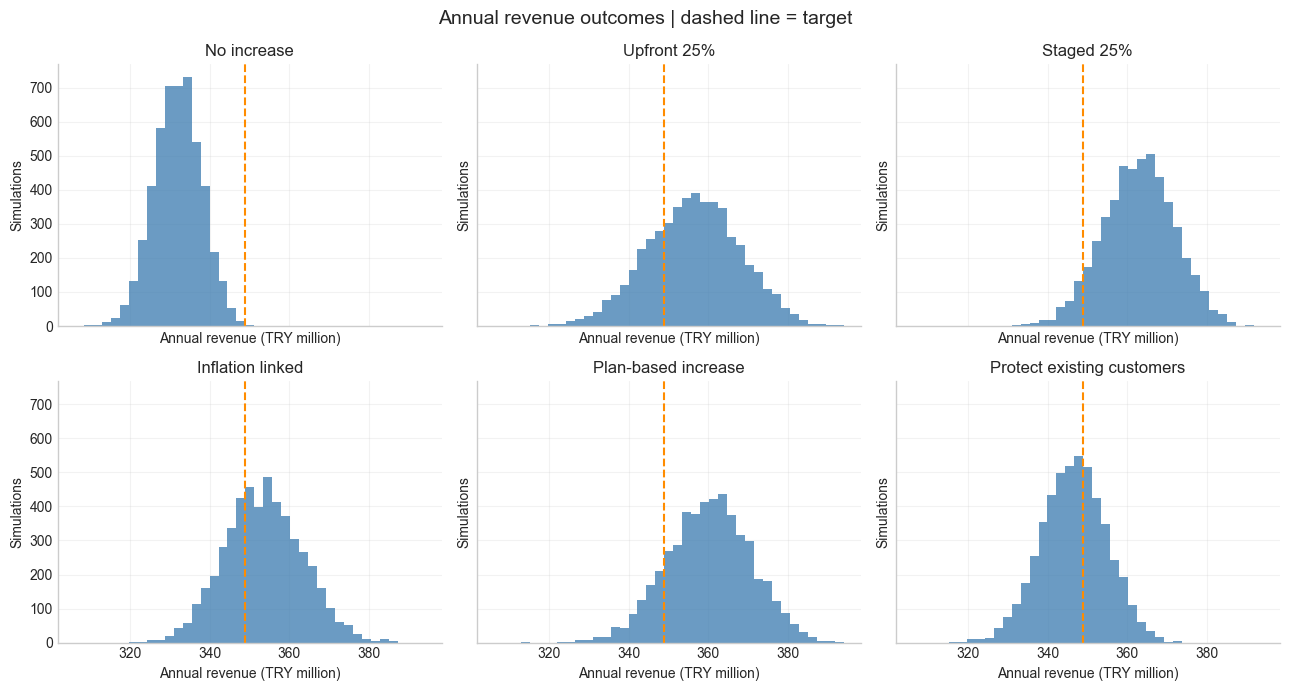

In [19]:
# Module 19: Compare annual revenue distributions

# An average can hide poor outcomes, so look at the full distributions.
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
all_revenue = np.concatenate([result["revenue"].sum(axis=1) / 1e6 for result in results.values()])
bins = np.linspace(all_revenue.min(), all_revenue.max(), 40)
for ax, (name, result) in zip(axes.flat, results.items()):
    annual_revenue = result["revenue"].sum(axis=1) / 1e6
    ax.hist(annual_revenue, bins=bins, color="steelblue", alpha=0.8)
    ax.axvline(target_revenue / 1e6, color="darkorange", linestyle="--")
    ax.set(title=name, xlabel="Annual revenue (TRY million)", ylabel="Simulations")
fig.suptitle("Annual revenue outcomes | dashed line = target", fontsize=14)
plt.tight_layout()
plt.show()

## Module 20 - Compare the chance of missing the target

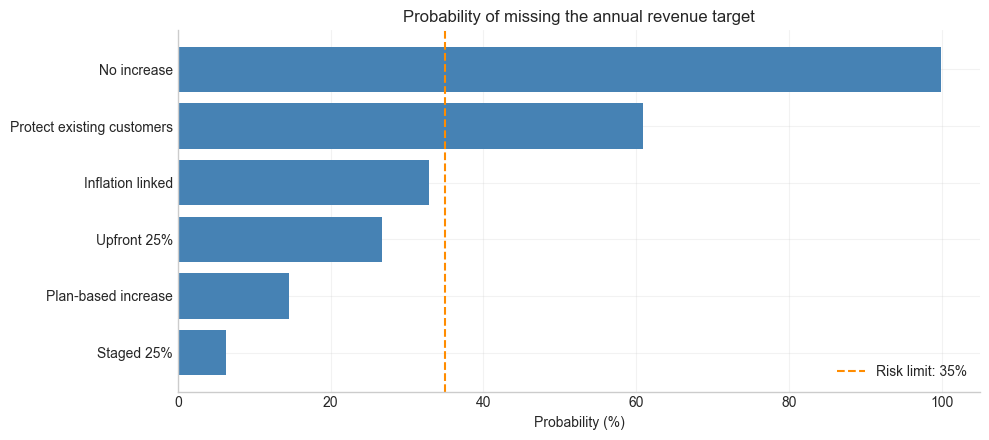

In [20]:
# Module 20: Compare the chance of missing the target

risk = summary["Miss target probability"].sort_values() * 100
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(risk.index, risk.values, color="steelblue")
ax.axvline(risk_limit * 100, color="darkorange", linestyle="--", label=f"Risk limit: {risk_limit:.0%}")
ax.set(xlabel="Probability (%)", title="Probability of missing the annual revenue target", xlim=(0, 105))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Module 21 - Follow revenue through the year

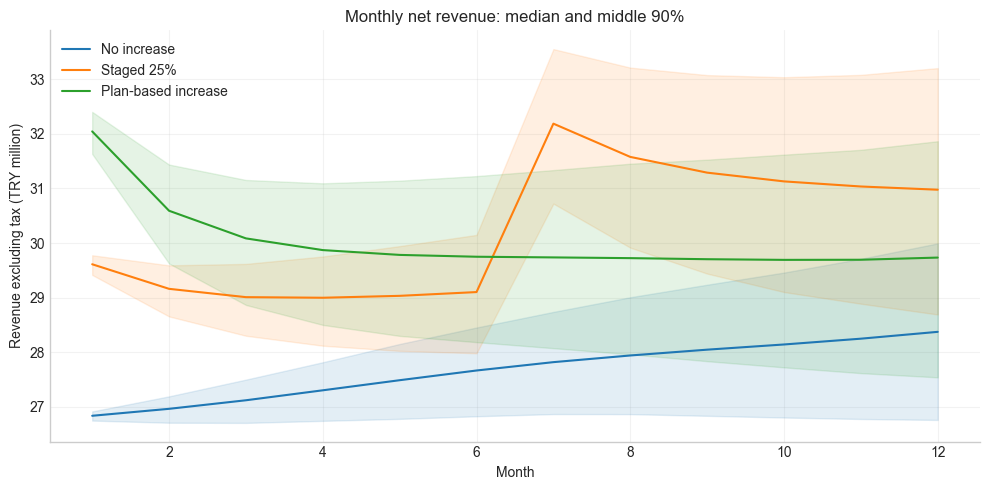

In [21]:
# Module 21: Follow revenue through the year

# Use three representative policies to keep the chart readable.
fig, ax = plt.subplots(figsize=(10, 5))
for name in ["No increase", "Staged 25%", "Plan-based increase"]:
    revenue = results[name]["revenue"] / 1e6
    low, median, high = np.percentile(revenue, [5, 50, 95], axis=0)
    line, = ax.plot(months, median, label=name)
    ax.fill_between(months, low, high, color=line.get_color(), alpha=0.12)
ax.set(title="Monthly net revenue: median and middle 90%", xlabel="Month", ylabel="Revenue excluding tax (TRY million)")
ax.legend()
plt.tight_layout()
plt.show()

## Module 22 - Compare contribution and customer retention

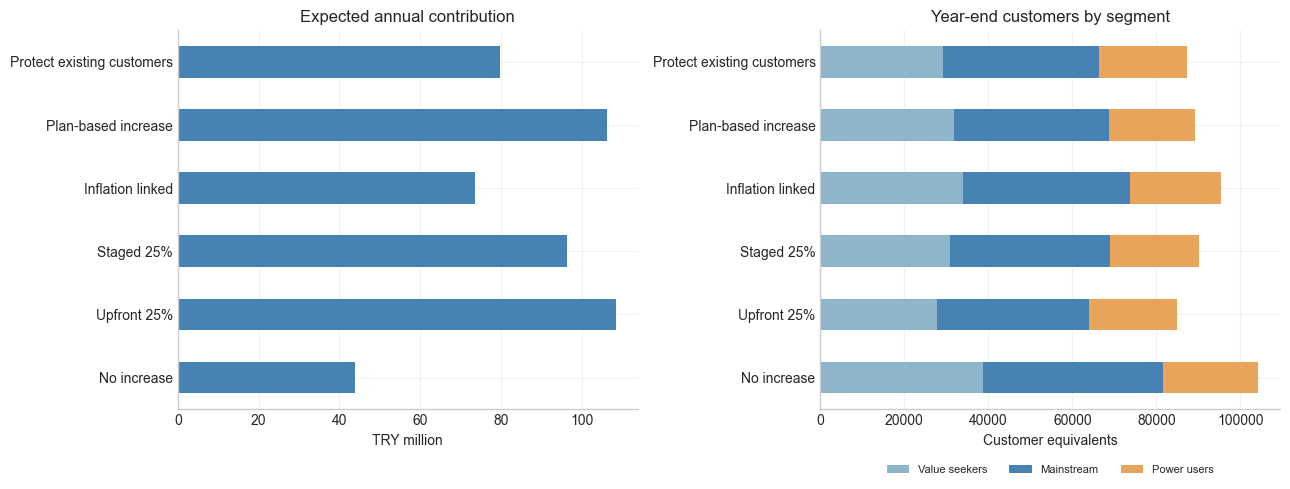

In [22]:
# Module 22: Compare contribution and customer retention

# Higher contribution can come with a smaller customer base.
ending_customers = pd.DataFrame({
    name: pd.Series(result["ending_by_group"].mean(axis=0)).groupby(groups["segment"]).sum()
    for name, result in results.items()
}).T.reindex(columns=segments.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
(summary["Expected contribution"] / 1e6).plot.barh(ax=axes[0], color="steelblue")
ending_customers.plot.barh(stacked=True, ax=axes[1], color=["#8db6cd", "#4682b4", "#e8a45b"])
axes[0].set(title="Expected annual contribution", xlabel="TRY million", ylabel="")
axes[1].set(title="Year-end customers by segment", xlabel="Customer equivalents", ylabel="")
axes[1].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()

## Module 23 - Test different levels of price sensitivity

Only acquisition elasticity changes here. The churn response stays the same.

In [23]:
# Module 23: Test different levels of price sensitivity

# Keep the economic paths fixed while changing acquisition elasticity.
# Recalculate the no-increase case each time, since elasticity affects that case too.
sensitivity_conditions = create_conditions(1000, seed + 10)
elasticity_multipliers = np.arange(0.5, 3.01, 0.25)
price_increases = np.arange(0.0, 0.51, 0.05)
sensitivity_rows = []

for multiplier in elasticity_multipliers:
    changed = {key: value.copy() for key, value in sensitivity_conditions.items()}
    changed["elasticity"] *= multiplier
    reference = simulate(scenarios["No increase"], changed)["revenue"].sum(axis=1)
    for increase in price_increases:
        scenario = {"type": "fixed", "increase": increase}
        revenue = simulate(scenario, changed)["revenue"].sum(axis=1)
        sensitivity_rows.append({"Elasticity multiplier": multiplier,
                                 "Price increase": increase,
                                 "Revenue difference": (revenue - reference).mean()})

sensitivity = pd.DataFrame(sensitivity_rows)

## Module 24 - Find where a price increase stops helping

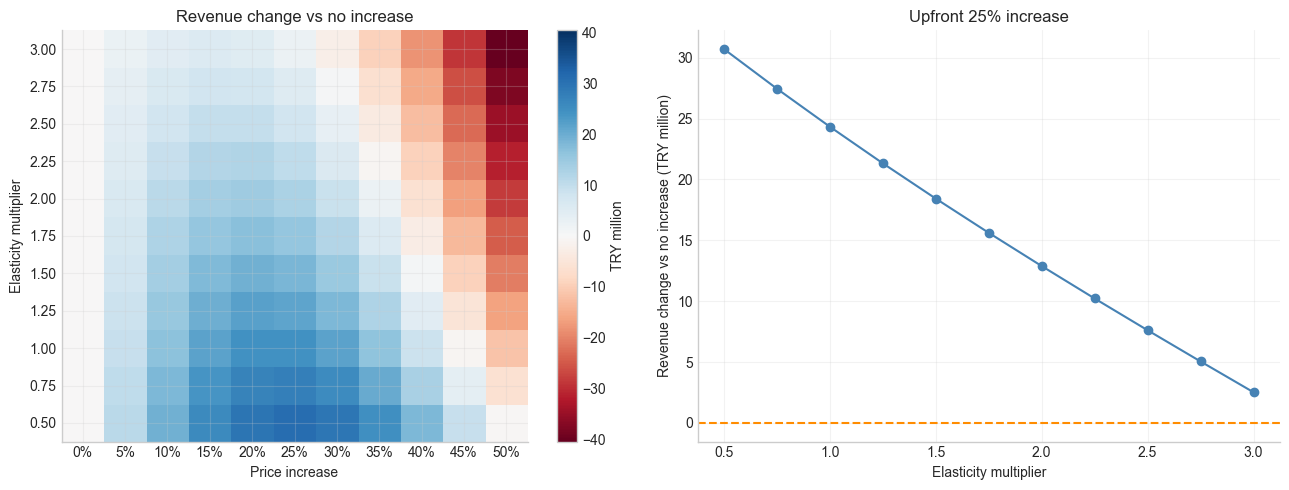

No break-even crossing was found in this range.


In [24]:
# Module 24: Find where a price increase stops helping

heatmap = sensitivity.pivot(index="Elasticity multiplier", columns="Price increase", values="Revenue difference") / 1e6
curve = sensitivity[np.isclose(sensitivity["Price increase"], 0.25)]
x = curve["Elasticity multiplier"].to_numpy()
y = curve["Revenue difference"].to_numpy() / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
limit = np.abs(heatmap.to_numpy()).max()
image = axes[0].imshow(heatmap, origin="lower", aspect="auto", cmap="RdBu", vmin=-limit, vmax=limit)
axes[0].set(xticks=range(len(price_increases)), xticklabels=[f"{p:.0%}" for p in price_increases],
            yticks=range(len(elasticity_multipliers)), yticklabels=[f"{e:.2f}" for e in elasticity_multipliers],
            xlabel="Price increase", ylabel="Elasticity multiplier", title="Revenue change vs no increase")
fig.colorbar(image, ax=axes[0], label="TRY million")
axes[1].plot(x, y, marker="o", color="steelblue")
axes[1].axhline(0, color="darkorange", linestyle="--")
axes[1].set(title="Upfront 25% increase", xlabel="Elasticity multiplier", ylabel="Revenue change vs no increase (TRY million)")
plt.tight_layout()
plt.show()

# Interpolate only when the sampled curve actually crosses zero.
# This is an approximate threshold, not an exact or universal value.
crossings = np.where(y[:-1] * y[1:] < 0)[0]
if len(crossings):
    i = crossings[0]
    break_even = x[i] - y[i] * (x[i + 1] - x[i]) / (y[i + 1] - y[i])
    print(f"The 25% increase loses its revenue advantage at about {break_even:.2f}x acquisition elasticity.")
else:
    print("No break-even crossing was found in this range.")

## Module 25 - Set up the stress tests

These are hypothetical shocks, with no assigned occurrence probabilities. The combined case adds 1.5 percentage points of monthly log-inflation and 0.50 to churn log-odds.

In [25]:
# Module 25: Set up the stress tests

stress_cases = {
    "Base": {},
    "FX +50%": {"fx": 1.50},
    "Demand -25%": {"demand": 0.75},
    "Higher price sensitivity": {"sensitivity": 1.50},
    "Combined stress": {"fx": 1.50, "demand": 0.65, "churn": 0.50, "extra_inflation": 0.015},
}

def apply_stress(economy, changes):
    # Work on copies so the base conditions stay unchanged.
    stressed = {key: value.copy() for key, value in economy.items()}
    start = 3  # Financial and demand shocks begin in month 4.
    stressed["fx"][:, start:] *= changes.get("fx", 1.0)
    stressed["demand"][:, start:] += np.log(changes.get("demand", 1.0))
    stressed["extra_churn"][:, start:] += changes.get("churn", 0.0)
    elapsed = np.arange(1, n_months - start + 1)
    stressed["cpi"][:, start:] *= np.exp(changes.get("extra_inflation", 0.0) * elapsed)

    # Higher price sensitivity affects both signups and price-induced churn from month 1.
    stressed["elasticity"] *= changes.get("sensitivity", 1.0)
    stressed["response"] *= changes.get("sensitivity", 1.0)
    return stressed

## Module 26 - Compare performance under stress

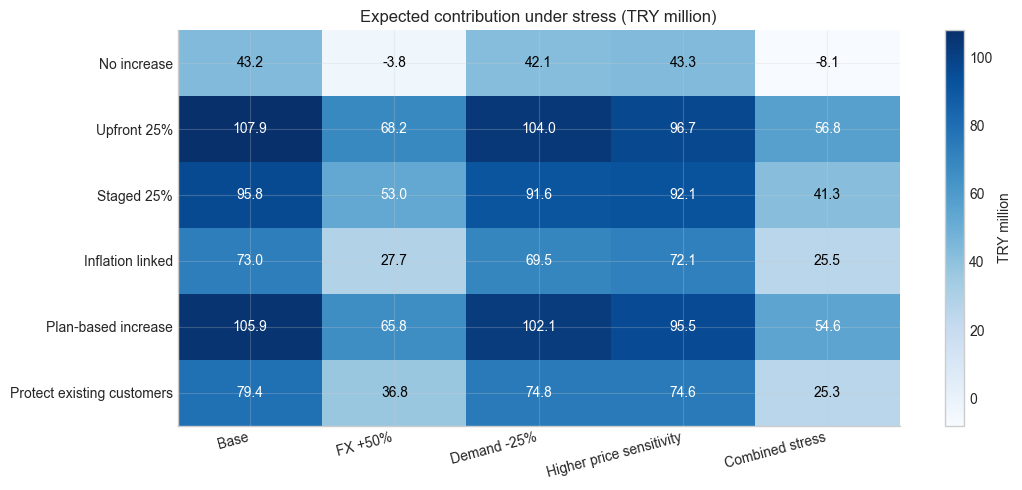

In [26]:
# Module 26: Compare performance under stress

stress_rows = []
for stress_name, changes in stress_cases.items():
    stressed = apply_stress(sensitivity_conditions, changes)
    for name, scenario in scenarios.items():
        result = simulate(scenario, stressed)
        stress_rows.append({"Scenario": name, "Stress": stress_name,
                            "Contribution": result["contribution"].sum(axis=1).mean(),
                            "Miss target": np.mean(result["revenue"].sum(axis=1) < target_revenue)})
stress_results = pd.DataFrame(stress_rows)
stress_table = stress_results.pivot(index="Scenario", columns="Stress", values="Contribution")
stress_table = stress_table.reindex(index=scenarios.keys(), columns=stress_cases.keys()) / 1e6

fig, ax = plt.subplots(figsize=(11, 5))
image = ax.imshow(stress_table, aspect="auto", cmap="Blues")
midpoint = (stress_table.to_numpy().min() + stress_table.to_numpy().max()) / 2
for row in range(len(stress_table)):
    for col in range(len(stress_table.columns)):
        value = stress_table.iloc[row, col]
        ax.text(col, row, f"{value:.1f}", ha="center", va="center", color="white" if value > midpoint else "black")
ax.set(xticks=range(len(stress_table.columns)), xticklabels=stress_table.columns,
       yticks=range(len(stress_table)), yticklabels=stress_table.index,
       title="Expected contribution under stress (TRY million)")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
fig.colorbar(image, ax=ax, label="TRY million")
plt.tight_layout()
plt.show()

## Module 27 - Search for a suitable price increase

Choose the highest expected contribution among candidates that stay within the revenue-risk limit and retain at least 95% of the starting customer base. This is a search over a fixed grid, not every possible pricing strategy.

In [27]:
# Module 27: Search for a suitable price increase

# Compare the original scenarios and a simple grid of upfront and staged increases.
# Use a separate sample for price selection.
search_conditions = create_conditions(3000, seed + 20)
candidates = scenarios.copy()
for kind in ["fixed", "staged"]:
    for increase in np.arange(0.0, 0.51, 0.05):
        name = f"{kind.title()} {increase:.0%}"
        candidates[name] = {"type": kind, "increase": increase}

search_rows = {name: summarize(simulate(scenario, search_conditions), target_revenue)
               for name, scenario in candidates.items()}
search_summary = pd.DataFrame(search_rows).T
feasible = search_summary[(search_summary["Miss target probability"] <= risk_limit)
                          & (search_summary["Ending customers"] >= customer_floor)]
feasible = feasible.sort_values("Expected contribution", ascending=False)
chosen_name = None if feasible.empty else feasible.index[0]

print(f"Candidates passing both limits: {len(feasible)} / {len(candidates)}")
print(f"Selected scenario: {chosen_name if chosen_name else 'No feasible scenario'}")
comparison_table(feasible.head(5))

Candidates passing both limits: 2 / 27
Selected scenario: Staged 15%


,Revenue (m TRY),Revenue P05 (m TRY),Miss target (%),Contribution (m TRY),Gross margin (%),Ending customers
Staged 15%,353.19,340.81,28.03,77.30,21.89,"96,331.89"
Inflation linked,353.45,337.97,32.40,73.73,20.86,"95,506.71"


## Module 28 - Look at the risk and contribution trade-off

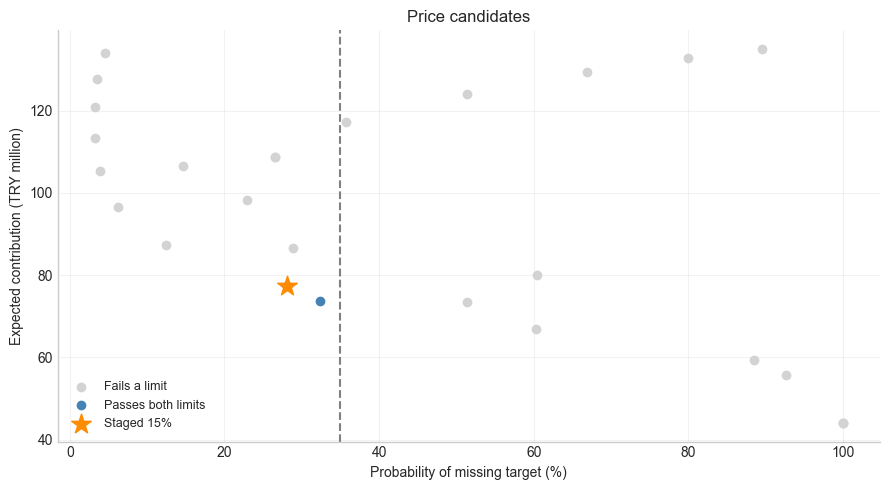

In [28]:
# Module 28: Look at the risk and contribution trade-off

fig, ax = plt.subplots(figsize=(9, 5))
passes = ((search_summary["Miss target probability"] <= risk_limit)
          & (search_summary["Ending customers"] >= customer_floor))
for mask, label, color in [(~passes, "Fails a limit", "lightgray"), (passes, "Passes both limits", "steelblue")]:
    ax.scatter(search_summary.loc[mask, "Miss target probability"] * 100,
               search_summary.loc[mask, "Expected contribution"] / 1e6, color=color, label=label)
if chosen_name is not None:
    chosen = search_summary.loc[chosen_name]
    ax.scatter(chosen["Miss target probability"] * 100, chosen["Expected contribution"] / 1e6,
               marker="*", s=220, color="darkorange", label=chosen_name, zorder=3)
ax.axvline(risk_limit * 100, linestyle="--", color="gray")
ax.set(title="Price candidates", xlabel="Probability of missing target (%)", ylabel="Expected contribution (TRY million)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Module 29 - Check the selected scenario on new simulations

The new sample checks whether the result holds up under fresh draws. Its risk estimate is still subject to simulation error; it does not validate the synthetic assumptions.

In [29]:
# Module 29: Check the selected scenario on new simulations

# Lock the selected scenario before generating fresh economic conditions.
selected_scenario = candidates[chosen_name] if chosen_name is not None else None
fresh_conditions = create_conditions(n_simulations, seed + 30)
fresh_baseline = simulate(scenarios["No increase"], fresh_conditions)
fresh_summary = None

if selected_scenario is not None:
    fresh_result = simulate(selected_scenario, fresh_conditions)
    fresh_summary = summarize(fresh_result, target_revenue)
    observed_risk = fresh_summary["Miss target probability"]
    observed_customers = fresh_summary["Ending customers"]
    print(f"Fresh-sample target-miss probability: {observed_risk:.1%}")
    print("Revenue-risk check:", "Within the limit" if observed_risk <= risk_limit else "Above the limit")
    print("Customer-floor check:", "Within the limit" if observed_customers >= customer_floor else "Below the limit")
    display(comparison_table(pd.DataFrame({chosen_name: fresh_summary}).T))
else:
    print("No scenario passed the search. The risk limit has not been changed.")

Fresh-sample target-miss probability: 27.1%
Revenue-risk check: Within the limit
Customer-floor check: Within the limit


,Revenue (m TRY),Revenue P05 (m TRY),Miss target (%),Contribution (m TRY),Gross margin (%),Ending customers
Staged 15%,353.37,340.57,27.14,77.01,21.79,"96,376.12"


## Module 30 - Summarize the result and save the comparison

The model now includes tax collection and payment commission. It still leaves out plan switching, individual customer histories and customer value beyond month 12.

In [30]:
# Module 30: Summarize the result and save the comparison

if fresh_summary is not None:
    baseline_contribution = fresh_baseline["contribution"].sum(axis=1).mean()
    baseline_customers = fresh_baseline["customers"][:, -1].mean()
    contribution_change = fresh_summary["Expected contribution"] - baseline_contribution
    customer_change_vs_baseline = fresh_summary["Ending customers"] / baseline_customers - 1
    customer_change_vs_start = fresh_summary["Ending customers"] / target_starting_customers - 1

    print(f"Selected pricing scenario: {chosen_name}")
    print(f"Expected net revenue: TRY {fresh_summary['Expected revenue'] / 1e6:.2f} million")
    print(f"Revenue at risk: TRY {fresh_summary['Revenue at risk'] / 1e6:.2f} million")
    print(f"Expected gross margin: {fresh_summary['Expected gross margin']:.1%}")
    print(f"Expected tax collected: TRY {fresh_summary['Tax collected'] / 1e6:.2f} million")
    print(f"Expected payment commission: TRY {fresh_summary['Payment commission'] / 1e6:.2f} million")
    print(f"Contribution change vs no increase: TRY {contribution_change / 1e6:+.2f} million")
    print(f"Year-end customer change vs starting base: {customer_change_vs_start:+.1%}")
    print(f"Year-end customer change vs no increase: {customer_change_vs_baseline:+.1%}")
    if np.isclose(selected_scenario.get("increase", -1), 0.50):
        print("The selected increase is at the 50% search limit; this does not establish a global optimum.")
    if fresh_summary["Miss target probability"] > risk_limit:
        print("The selected scenario did not meet the risk limit on the fresh sample.")
    if fresh_summary["Ending customers"] < customer_floor:
        print("The selected scenario fell below the customer floor on the fresh sample.")
else:
    print("No pricing scenario met the chosen target and risk limit.")

# Save one useful comparison file next to the notebook. Re-running replaces this file.
summary.to_csv("pricing_comparison.csv")
print("Saved pricing_comparison.csv")

Selected pricing scenario: Staged 15%
Expected net revenue: TRY 353.37 million
Revenue at risk: TRY 8.34 million
Expected gross margin: 21.8%
Expected tax collected: TRY 88.34 million
Expected payment commission: TRY 6.63 million
Contribution change vs no increase: TRY +33.28 million
Year-end customer change vs starting base: -3.6%
Year-end customer change vs no increase: -7.6%
Saved pricing_comparison.csv
